## Download and understanding IBL dataset


In [465]:
# Imports
from one.api import ONE
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt


In [466]:
# Using ONE's ```load_aggregate``` function, we can retrieve all sessions from a given animal. For this, first we need to instantiate the ```ONE``` object
one = ONE()

# Then we need to choose our subject and run ```load_aggregate```
subject = "CSHL_008"
trials = one.load_aggregate('subjects', subject, '_ibl_subjectTrials.table')

# We can see the information we get by printing the columns
print(trials.columns)

/Users/camilamaura/coding_projects/glm_hmm_notebook/.venv/lib/python3.12/site-packages/one/util.py:442: ALFWarning: No default revision for dataset aggregates/Subjects/churchlandlab/CSHL_008/_ibl_subjectTrials.table.pqt; using most recent
  warnings.warn(


Index(['intervals_0', 'intervals_1', 'goCue_times', 'response_times', 'choice',
       'stimOn_times', 'contrastLeft', 'contrastRight', 'feedback_times',
       'feedbackType', 'rewardVolume', 'probabilityLeft',
       'firstMovement_times', 'goCueTrigger_times', 'stimOnTrigger_times',
       'stimOffTrigger_times', 'stimFreezeTrigger_times', 'stimOff_times',
       'stimFreeze_times', 'phase', 'position', 'quiescence', 'session',
       'task_protocol', 'protocol_number', 'session_start_time'],
      dtype='object')


! Admonition one.search() returns session IDs (eids) that exist as session records in Alyx, while load_aggregate() downloads a pre computed file with trial data pooled across multiple sessions. If you want to get all sessions from a single animal, it is recommended to use ```load_aggregate```, because some sessions may be located in a dataframe without a session identified in itself (but containing multiple sessions with their own session identifiers). 

We are modeling choice as result of observables and behavioral state. Thus, we need choice, stimuli presented and reward obtained. Additionally, we want to keep the session identifier, date of occurence for plotting. Furthermore, in this task, the probability of the stimulus being in the left or the right side of the screen changes over time within a session. Thus, we also want the information of the probability of the stimulus being in a given position.
Let's extract the meaningful data: 
| Variable            | Description |
|---------------------|-------------|
| session             | id of session |
| choice              | mouse choice: 1 = correct response for stimulus on left, -1 = correct response for stimulus on right, 0 = violation (no response) |
| contrastLeft        | contrast of stimulus presented on the left |
| contrastRight       | contrast of stimulus presented on the right |
| feedbackType        | reward obtained |
| probabilityLeft     | probability of stimulus being presented on the right |
| session_start_time  | date and time of start of session |

In [467]:
trials = trials[["session", "choice", "contrastLeft", "contrastRight", "feedbackType", "probabilityLeft", "session_start_time"]]

Now, we will restrict the analysis to the first 90 trials of each session. In this segment, the stimulus appears on the left and right with equal probability (0.5/0.5). After trial 90, the task switches to a block structure in which the left stimulus occurs with probability 0.8 or 0.2, alternating across blocks within the session.

The rationale for focusing on the initial 50–50 trials is to isolate baseline behavior without block-induced biases. In that regime, choices are driven primarily by sensory evidence rather than learned expectations about stimulus probability

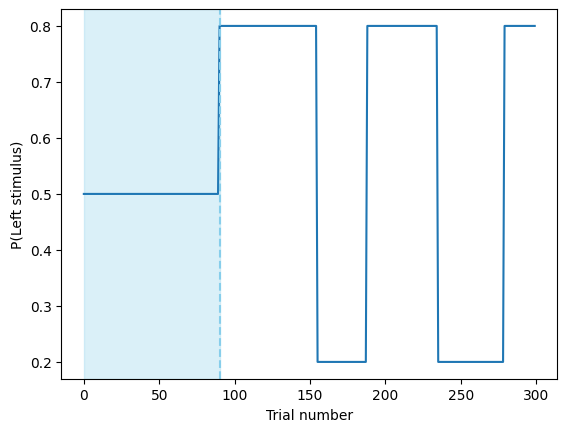

In [468]:
sess = '726b6915-e7de-4b55-a38e-ff4c461211d3'
trials_sess = trials[trials.session == sess].reset_index()

plt.plot(trials_sess["probabilityLeft"][:300])

plt.axvspan(0, 90, color="skyblue", alpha=0.3, label="first 90 trials")
plt.axvline(90, color="skyblue", linestyle="--")

plt.ylabel("P(Left stimulus)")
plt.xlabel("Trial number")
plt.show()

In Ashwood, only the sessions with less than 10 violations were used. Thus, we will now revise the number of violations, defined as a trial where the animal made no choice. i.e choice == 0 during the 50-50 trials. For that:
 1) 50-50 trials must be present and 
 2) there must be less than 10 violations in that subset of trials

In [469]:
# Create a list of ids
sessions_ids = trials.session.unique()

# keep only relevant columns for filtering
df_trials = trials[["session", "probabilityLeft", "choice"]]

# Get which sessions contain exactly {0.2, 0.5, 0.8}
valid_prob_sessions = (
    df_trials.groupby("session")["probabilityLeft"]
      .agg(lambda x: set(x.unique()) == {0.2, 0.5, 0.8})
)
# Compute violations only on 50-50 trials
violations = (
    df_trials[df_trials["probabilityLeft"] == 0.5]
    .groupby("session")["choice"]
    .apply(lambda x: (x == 0).sum())
)
# Apply both restrictions
valid_sessions = violations[
    (violations < 10) & (violations.index.isin(valid_prob_sessions[valid_prob_sessions == True].index))
].index.tolist()

# Make sure they maintain the order of the original dataset (we don't want scrambled trials)
valid_set = set(valid_sessions)
valid_sessions = [
    s for s in trials["session"].drop_duplicates()
    if s in valid_set
]
print(f"# of sessions before restrictions {len(df_trials.session.unique())}")

# Now we can select only the valid sessions for subsequent analyses
df_trials = trials[
    (trials["session"].isin(valid_sessions)) & (df_trials["probabilityLeft"] == 0.5)
]
print(f"# of sessions after restrictions {len(df_trials.session.unique())}")

# of sessions before restrictions 73
# of sessions after restrictions 56


:: admonition for filtering rationale, although i believe it might not be necessary

## Building the design matrix
Now, with the valid sessions, we can compute the design matrix. In our case, we are interested in building a design matrix with three predictors: stimuli, previous choice and win stay lose shift.

<center><img src="images/design_matrix_table.png" alt="Task schematic" width="1000" /></center>

In [470]:
# Select an example session
eid = valid_sessions[0]     
# Filter that session
df_sess = df_trials[df_trials["session"] == eid]

# We can select all the necessary values for the design matrix: choice, contrast of stimuli and reward
choice = df_sess['choice'].reset_index(drop=True)
stim_left = df_sess['contrastLeft'].reset_index(drop=True)
stim_right = df_sess['contrastRight'].reset_index(drop=True)
rewarded = df_sess['feedbackType'].reset_index(drop=True)

In [471]:
# Create stim vector
stim_left = np.nan_to_num(stim_left, nan=0)
stim_right = np.nan_to_num(stim_right, nan=0)

# now get 1D stim
signed_contrast = stim_right - stim_left

Now we will create the next predictor: previous choice

In [472]:
# Remap values to {1,0,-1}
# # raw choice vector has CW = 1 (correct response for stim on left),
    # CCW = -1 (correct response for stim on right) and viol = 0.  Let's
    # remap so that CW = 0, CCw = 1, and viol = -1
choice = choice.replace({1: 0, -1: 1, 0: -1})

# Get rid of violation trials i.e trials where the mouse didn't make a choice
# previous choice vector getting rid of violation trials
valid_choices_idx = np.where(~choice.isin([-1]))[0]      # violations are -1
valid_choices = choice[valid_choices_idx]

# Shift the array elements one position to the right
previous_choice = np.roll(valid_choices, 1)
# Set first choice as first previous_choice
previous_choice[0] = valid_choices[0]

Now we will compute the final predictor: win-stay lose-shift

In [473]:
# remap previous choice vals to {-1, 1}
remapped_previous_choice = 2 * previous_choice - 1
# Keep only rewards corresponding to valid trials
valid_rewards = rewarded[valid_choices_idx]

# Shift the array elements one position to the right
previous_reward = np.roll(valid_rewards, 1)
# Set first choice as first previous_choice
previous_reward[0] = valid_rewards[0]

# wsls: vector of size T, entries are in {-1, 1}.  1 corresponds to previous choice = right and success OR previous choice = left and failure; -1 corresponds to previous choice = left and success OR previous choice = right and failure
wsls = previous_reward * remapped_previous_choice

Now can create our design matrix and fill it with the three vectors: stimuli, previous choice and wsls.

In [474]:
# Remove stimuli of invalid choices
signed_contrast =  signed_contrast[valid_choices_idx]
# Create matrix to be filled with the predictors
n_trials = len(signed_contrast)
# Create empty design matrix of shape (n_trials, n_predictors)
design_mat = np.zeros((n_trials, 3))
# Add signed_contrast in the first predictor in the design matrix
design_mat[:, 0] = signed_contrast
# map previous choice to {-1,1} and add to second predictor in the design matrix
design_mat[:, 1] = 2 * previous_choice - 1
# Add wsls as third predictor in the design matrix
design_mat[:, 2] = wsls

We then normalize stimuli values across trials.

In [475]:
unnormalized_inpt = design_mat.copy()
normalized_inpt = np.copy(unnormalized_inpt)
normalized_inpt[:, 0] = preprocessing.scale(normalized_inpt[:, 0])

and see our design matrix.

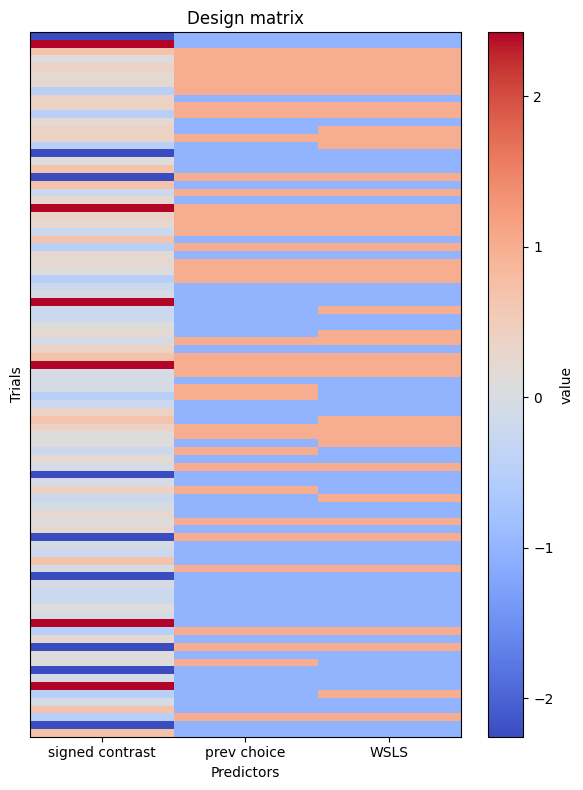

In [476]:
X = normalized_inpt.copy()

plt.figure(figsize=(6,8))

plt.imshow(X, aspect="auto", cmap="coolwarm", interpolation="nearest")

plt.colorbar(label="value")

plt.xticks([0,1,2], ["signed contrast", "prev choice", "WSLS"])
plt.yticks([])

plt.xlabel("Predictors")
plt.ylabel("Trials")
plt.title("Design matrix")

plt.tight_layout()
plt.show()

Comment? Not super useful really

We will carry out the exact same process but for all trials. Our design matrix each row will be a trial, so effectively this means that we will carry out the same process up until the normalization and then normalize.

In [477]:
def get_data_this_session(eid, df_trials):
    df_sess = df_trials[df_trials["session"] == eid]
    stim_left = df_sess['contrastLeft'].reset_index(drop=True)
    stim_right = df_sess['contrastRight'].reset_index(drop=True)
    rewarded = df_sess['feedbackType'].reset_index(drop=True)
    choice = df_sess['choice'].reset_index(drop=True)
    return choice, stim_left, stim_right, rewarded

def get_valid_choice(choice):
    # takes in remapped choices
    # Get rid of violation trials i.e trials where the mouse didn't make a choice
    # previous choice vector getting rid of violation trials
    valid_choices_idx = np.where(~choice.isin([-1]))[0]      # violations are -1
    valid_choices = choice[valid_choices_idx]
    return valid_choices, valid_choices_idx
    

def create_previous_choice_vector(valid_choices):
    # takes in already remapped valid choices and .
    
    # Shift the array elements one position to the right
    previous_choice = np.roll(valid_choices, 1)
    # Set first choice as first previous_choice
    previous_choice[0] = valid_choices[0]
    return previous_choice
        
def create_stim_vector(stim_left, stim_right):
    # Create stim vector
    stim_left = np.nan_to_num(stim_left, nan=0)
    stim_right = np.nan_to_num(stim_right, nan=0)
    # now get 1D stim
    signed_contrast = stim_right - stim_left
    return signed_contrast

def create_wsls_covariate(previous_choice, rewarded, valid_choices_idx):
    '''
    inputs:
    previous_choice: vector of size T, entries are in {0, 1} and 0
    corresponds to left choice, 1 corresponds to right choice
    
    rewarded: vector of size T, entries are in {-1, 1} and -1 corresponds to
    failure, 1 corresponds to success
    valid_choices_idx : idx of valid trials
    
    wsls: vector of size T, entries are in {-1, 1}.  1 corresponds to
    previous choice = right and success OR previous choice = left and
    failure; -1 corresponds to previous choice = left and success OR previous choice = right and failure
    '''
    # remap previous choice vals to {-1, 1}
    remapped_previous_choice = 2 * previous_choice - 1
    # Keep only rewards corresponding to valid trials
    valid_rewards = rewarded[valid_choices_idx]

    # Shift the array elements one position to the right
    previous_reward = np.roll(valid_rewards, 1)
    # Set first choice as first previous_choice
    previous_reward[0] = valid_rewards[0]
    # wsls: vector of size T, entries are in {-1, 1}.  1 corresponds to previous choice = right and success OR previous choice = left and failure; -1 corresponds to previous choice = left and success OR previous choice = right and failure
    wsls = previous_reward * remapped_previous_choice
    assert len(np.unique(wsls)) == 2, "wsls should be in {-1, 1}"
    return wsls

def remap_choice_vals(choice):
    # raw choice vector has CW = 1 (correct response for stim on left),
    # CCW = -1 (correct response for stim on right) and viol = 0.  Let's
    # remap so that CW = 0, CCw = 1, and viol = -1
    new_choice = choice.replace({1: 0, -1: 1, 0: -1})
    return new_choice

def create_design_matrix(choice, stim_left, stim_right, rewarded):
    # Stimuli predictor
    signed_contrast = create_stim_vector(stim_left, stim_right)

    # make choice vector so that correct response for stim>0 is choice =1
    # and is 0 for stim <0 (viol is mapped to -1)
    choice = remap_choice_vals(choice)
    valid_choices, valid_choices_idx = get_valid_choice(choice)
    previous_choice = create_previous_choice_vector(valid_choices)

    # create wsls vector:
    wsls = create_wsls_covariate(previous_choice, rewarded, valid_choices_idx)
    
    signed_contrast =  signed_contrast[valid_choices_idx]
    
    n_trials = len(signed_contrast)
    design_mat = np.zeros((n_trials, 3))
    design_mat[:, 0] = signed_contrast    

    # map previous choice to {-1,1}
    design_mat[:, 1] = 2 * previous_choice - 1
    design_mat[:, 2] = wsls
    return design_mat

def get_all_unnormalized_data_this_session(eid, df_trials):
    choice, stim_left, stim_right, rewarded = get_data_this_session(eid, df_trials)
    unnormalized_design_matrix = create_design_matrix(choice, stim_left, stim_right, rewarded)
    y = np.expand_dims(remap_choice_vals(choice), axis=1)
    session = [eid for i in range(y.shape[0])]
    rewarded = np.expand_dims(rewarded, axis=1)
    return unnormalized_design_matrix, y, session, rewarded

def get_unnormalized_design_mat(valid_sessions, df_trials):
    sess_counter = 0
    for eid in valid_sessions:
        unnormalized_inpt, y, session, rewarded = \
            get_all_unnormalized_data_this_session(
                eid, df_trials)
        if sess_counter == 0:
            animal_unnormalized_inpt = np.copy(unnormalized_inpt)
            animal_y = np.copy(y)
            animal_session = session
            animal_rewarded = np.copy(rewarded)
        else:
            animal_unnormalized_inpt = np.vstack(
                (animal_unnormalized_inpt, unnormalized_inpt))
            animal_y = np.vstack((animal_y, y))
            animal_session = np.concatenate((animal_session, session))
            animal_rewarded = np.vstack((animal_rewarded, rewarded))
        sess_counter += 1
    # Normalize
    animal_normalized_inpt = np.copy(animal_unnormalized_inpt)
    animal_normalized_inpt[:, 0] = preprocessing.scale(animal_unnormalized_inpt[:, 0])
    
    return animal_unnormalized_inpt, animal_normalized_inpt, animal_y, animal_session

In [478]:
animal_unnormalized_inpt, animal_normalized_inpt, animal_y, animal_session = get_unnormalized_design_mat(valid_sessions, df_trials)